# MNIST Handwritten Digit Classification using CNN

## Project Overview
A professional implementation of a Convolutional Neural Network (CNN) for classifying handwritten digits from the MNIST dataset using PyTorch.

---

## Workflow
1. **Import Libraries** → Load required packages and dependencies
2. **Load Dataset** → Download and prepare MNIST dataset
3. **Create DataLoader** → Organize data into batches
4. **Build CNN Model** → Design neural network architecture
5. **Define Loss Function** → Set CrossEntropyLoss for multi-class classification
6. **Define Optimizer** → Initialize Adam optimizer
7. **Train Model** → Train the model on training data
8. **Evaluate Model** → Assess accuracy on test data
9. **Save Model** → Persist trained weights
10. **Make Predictions** → Test on new samples with visualization

In [28]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Visualization imports
import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import numpy as np

# Set professional style
style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [ ]:
# Apply data normalization for better model performance
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
])

# Load training dataset
train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Load test dataset
test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print(f" Datasets loaded successfully")

✓ Datasets loaded successfully


In [30]:
# Display dataset information
train_size = len(train_dataset)
test_size = len(test_dataset)

print(f"Training Dataset Size: {train_size:,} samples")
print(f"Test Dataset Size: {test_size:,} samples")
print(f"Total Dataset Size: {train_size + test_size:,} samples")
print(f"Number of Classes: 10 (digits 0-9)")

Training Dataset Size: 60,000 samples
Test Dataset Size: 10,000 samples
Total Dataset Size: 70,000 samples
Number of Classes: 10 (digits 0-9)


In [ ]:
# Create data loaders with optimized batch size and workers
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

num_batches_train = len(train_loader)
num_batches_test = len(test_loader)

print(f"Training DataLoader: {num_batches_train} batches")
print(f" Test DataLoader: {num_batches_test} batches")

✓ Training DataLoader: 938 batches
✓ Test DataLoader: 157 batches


In [32]:
class MNISTCNN(nn.Module):
    """
    Convolutional Neural Network for MNIST digit classification.
    Architecture:
    - 2 Convolutional Layers (16 and 32 filters)
    - 2 MaxPooling Layers
    - Fully Connected Layers (128 -> 10)
    """
    def __init__(self):
        super().__init__()
        
        # Feature extraction layers
        self.features = nn.Sequential(
            # First convolutional block
            nn.Conv2d(
                in_channels=1,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            
            # Second convolutional block
            nn.Conv2d(
                16,
                32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        # Classification layers
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [33]:
# Initialize model
model = MNISTCNN()

# Print model architecture
print("="*60)
print("MODEL ARCHITECTURE")
print("="*60)
print(model)

# Count model parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nTotal Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print("="*60)

MODEL ARCHITECTURE
MNISTCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total Parameters: 206,922
Trainable Parameters: 206,922


In [34]:
# Define loss function for multi-class classification
criterion = nn.CrossEntropyLoss()
print(f"✓ Loss Function: CrossEntropyLoss")

✓ Loss Function: CrossEntropyLoss


In [35]:
# Initialize optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    betas=(0.9, 0.999),
    eps=1e-08,
    weight_decay=0
)

print(f"✓ Optimizer: Adam")
print(f"✓ Learning Rate: 0.001")

✓ Optimizer: Adam
✓ Learning Rate: 0.001


In [36]:
# Training loop with metrics tracking
train_losses = []
train_accuracies = []

epochs = 5

print("\n" + "="*60)
print("TRAINING PHASE")
print("="*60)

for epoch in range(epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Metrics
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # Calculate epoch metrics
    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total
    
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(f"Epoch [{epoch+1:2d}/{epochs}] | Loss: {epoch_loss:.4f} | Accuracy: {epoch_accuracy:.2f}%")

print("="*60)


TRAINING PHASE


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [ 1/5] | Loss: 0.2586 | Accuracy: 92.03%
Epoch [ 2/5] | Loss: 0.0964 | Accuracy: 97.14%
Epoch [ 3/5] | Loss: 0.0736 | Accuracy: 97.81%
Epoch [ 4/5] | Loss: 0.0600 | Accuracy: 98.20%
Epoch [ 5/5] | Loss: 0.0539 | Accuracy: 98.36%


In [37]:
# Evaluation on test set with detailed metrics
print("\n" + "="*60)
print("EVALUATION PHASE")
print("="*60)

model.eval()
correct = 0
total = 0
all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")
print(f"Correct Predictions: {correct}/{total}")
print("="*60)


EVALUATION PHASE
Test Accuracy: 98.76%
Correct Predictions: 9876/10000


In [38]:
# Save trained model
model_save_path = "mnist_cnn.pth"
torch.save(model.state_dict(), model_save_path)
print(f"✓ Model saved to '{model_save_path}'")

✓ Model saved to 'mnist_cnn.pth'


In [39]:
import os

# Verify model file exists
model_exists = os.path.exists(model_save_path)
model_size = os.path.getsize(model_save_path) / (1024 * 1024) if model_exists else 0

print(f"Model File Exists: {model_exists}")
print(f"Model File Size: {model_size:.2f} MB")

Model File Exists: True
Model File Size: 0.79 MB


In [40]:
# Get sample batch for predictions
images, labels = next(iter(test_loader))

# Make predictions
model.eval()
with torch.no_grad():
    outputs = model(images)
    _, predictions = torch.max(outputs, 1)

# Display predictions for first 10 samples
print("Sample Predictions (First 10):")
print("-" * 50)
for i in range(10):
    match = "✓" if predictions[i].item() == labels[i].item() else "✗"
    print(f"{match} Predicted: {predictions[i].item()} | Actual: {labels[i].item()}")

Sample Predictions (First 10):
--------------------------------------------------
✓ Predicted: 7 | Actual: 7
✓ Predicted: 2 | Actual: 2
✓ Predicted: 1 | Actual: 1
✓ Predicted: 0 | Actual: 0
✓ Predicted: 4 | Actual: 4
✓ Predicted: 1 | Actual: 1
✓ Predicted: 4 | Actual: 4
✓ Predicted: 9 | Actual: 9
✓ Predicted: 5 | Actual: 5
✓ Predicted: 9 | Actual: 9


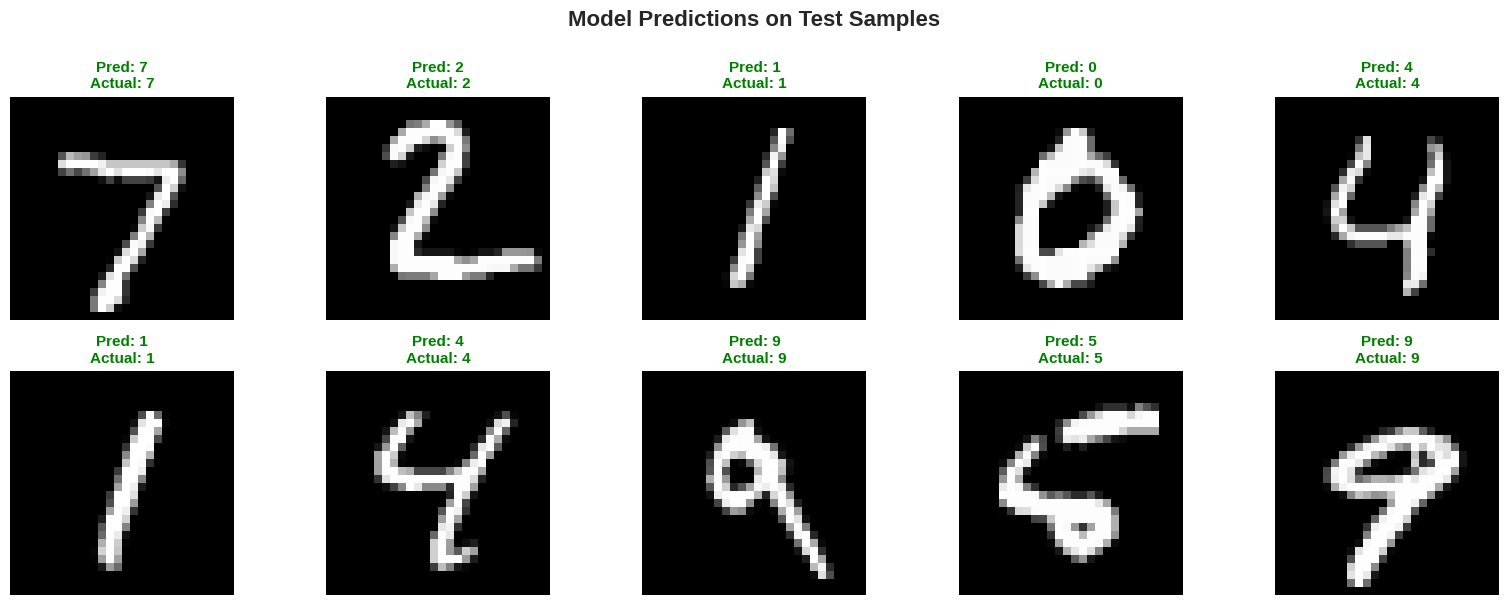

In [41]:
# Visualization: Sample predictions with grid
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
fig.suptitle("Model Predictions on Test Samples", fontsize=16, fontweight='bold', y=1.00)

for i in range(10):
    ax = axes[i // 5, i % 5]
    
    # Display image
    ax.imshow(images[i].squeeze(), cmap='gray', interpolation='nearest')
    
    # Color based on correctness
    is_correct = predictions[i].item() == labels[i].item()
    border_color = 'green' if is_correct else 'red'
    title_color = 'green' if is_correct else 'red'
    
    # Set border
    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(3)
    
    # Title with prediction and actual
    title = f"Pred: {predictions[i].item()}\nActual: {labels[i].item()}"
    ax.set_title(title, fontsize=11, fontweight='bold', color=title_color)
    ax.axis('off')

plt.tight_layout()
plt.savefig("predictions_grid.png", dpi=300, bbox_inches='tight')
plt.show()

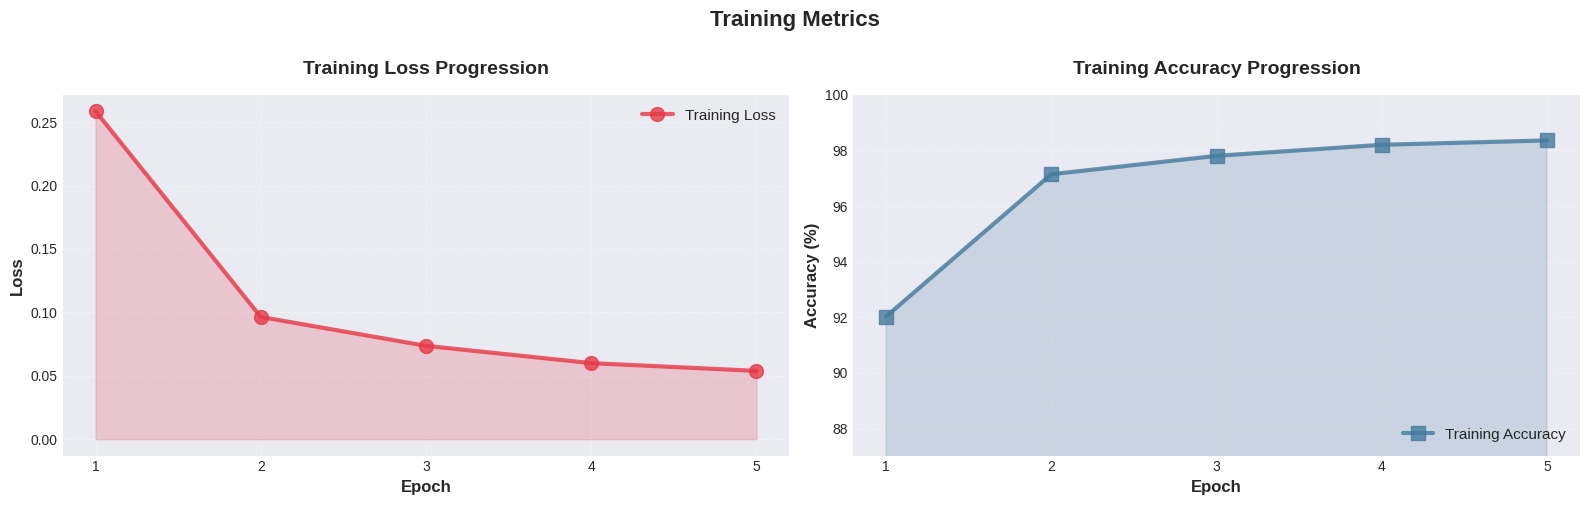

In [42]:
# Visualization: Training metrics with dual axes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Loss curve
ax1.plot(range(1, epochs + 1), train_losses, 
         linewidth=3, marker='o', markersize=10, 
         label='Training Loss', color='#E63946', alpha=0.8)
ax1.fill_between(range(1, epochs + 1), train_losses, alpha=0.2, color='#E63946')
ax1.set_xlabel("Epoch", fontsize=12, fontweight='bold')
ax1.set_ylabel("Loss", fontsize=12, fontweight='bold')
ax1.set_title("Training Loss Progression", fontsize=14, fontweight='bold', pad=15)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(fontsize=11, loc='upper right')
ax1.set_xticks(range(1, epochs + 1))

# Plot 2: Accuracy curve
ax2.plot(range(1, epochs + 1), train_accuracies, 
         linewidth=3, marker='s', markersize=10, 
         label='Training Accuracy', color='#457B9D', alpha=0.8)
ax2.fill_between(range(1, epochs + 1), train_accuracies, alpha=0.2, color='#457B9D')
ax2.set_xlabel("Epoch", fontsize=12, fontweight='bold')
ax2.set_ylabel("Accuracy (%)", fontsize=12, fontweight='bold')
ax2.set_title("Training Accuracy Progression", fontsize=14, fontweight='bold', pad=15)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(fontsize=11, loc='lower right')
ax2.set_xticks(range(1, epochs + 1))
ax2.set_ylim([min(train_accuracies) - 5, 100])

plt.suptitle("Training Metrics", fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig("training_metrics.png", dpi=300, bbox_inches='tight')
plt.show()

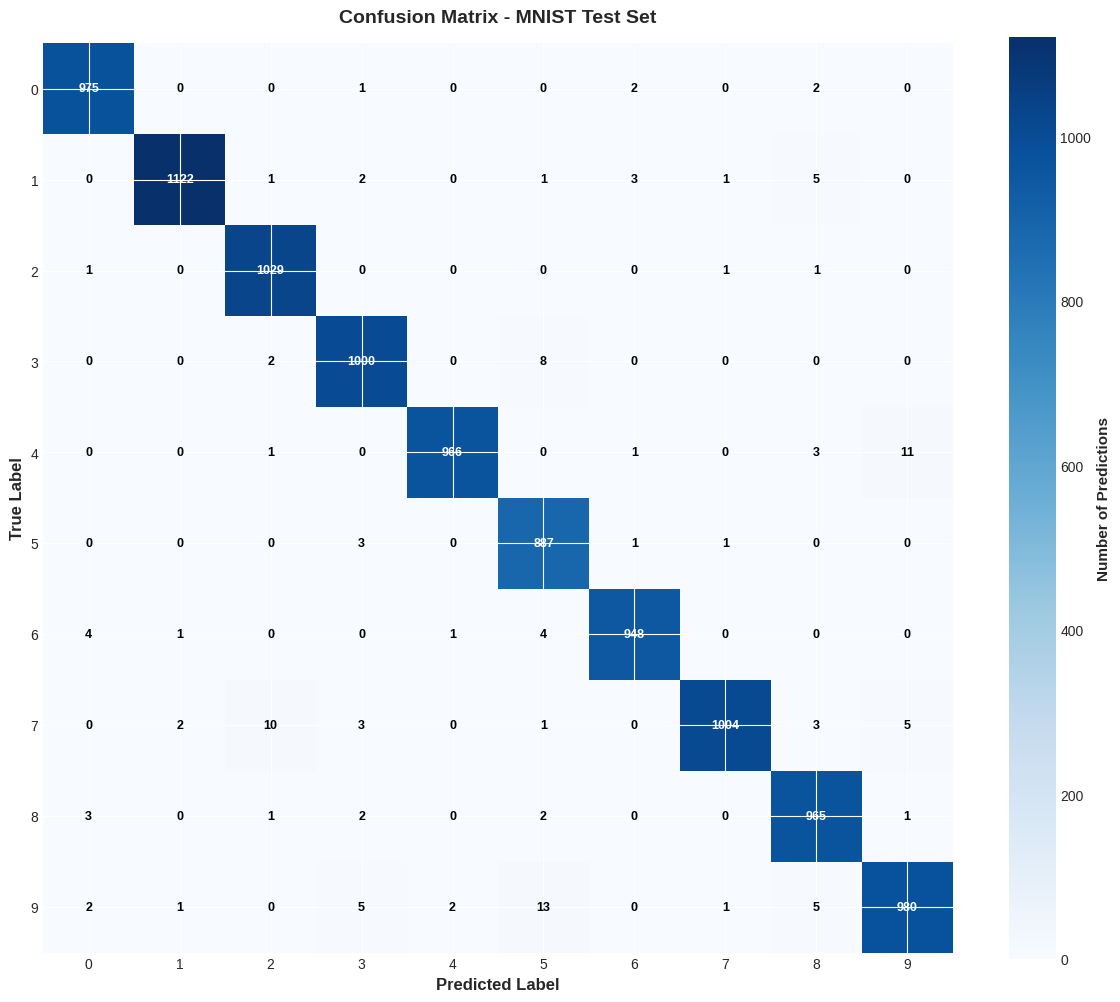

In [43]:
# Visualization: Confusion Matrix
from sklearn.metrics import confusion_matrix
import numpy as np

# Calculate confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Number of Predictions', fontsize=11, fontweight='bold')

# Set ticks and labels
tick_marks = np.arange(10)
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(range(10), fontsize=10)
ax.set_yticklabels(range(10), fontsize=10)

# Add text annotations
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        text = ax.text(j, i, cm[i, j],
                      ha="center", va="center",
                      color="white" if cm[i, j] > cm.max() / 2 else "black",
                      fontsize=9, fontweight='bold')

# Labels and title
ax.set_xlabel("Predicted Label", fontsize=12, fontweight='bold')
ax.set_ylabel("True Label", fontsize=12, fontweight='bold')
ax.set_title("Confusion Matrix - MNIST Test Set", fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

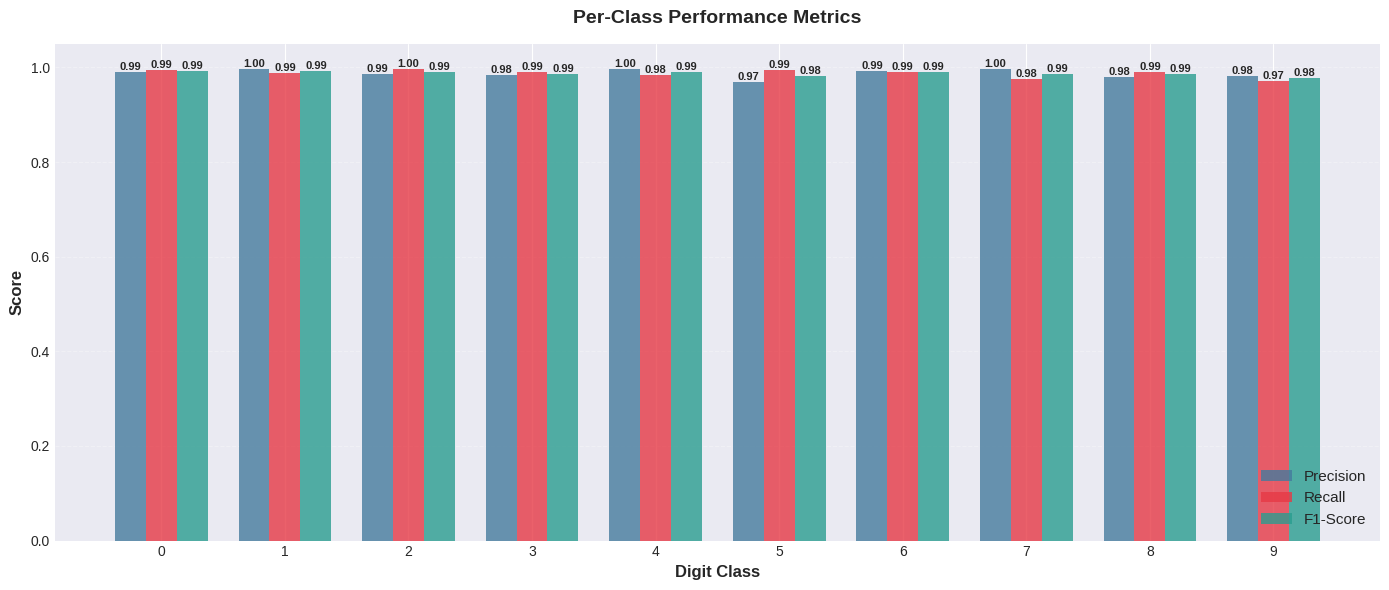


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       1.00      0.99      0.99      1135
           2       0.99      1.00      0.99      1032
           3       0.98      0.99      0.99      1010
           4       1.00      0.98      0.99       982
           5       0.97      0.99      0.98       892
           6       0.99      0.99      0.99       958
           7       1.00      0.98      0.99      1028
           8       0.98      0.99      0.99       974
           9       0.98      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [44]:
# Visualization: Per-class accuracy (Classification Report)
from sklearn.metrics import classification_report

# Generate classification report
report_dict = classification_report(all_labels, all_predictions, output_dict=True)

# Extract per-class metrics
classes = list(range(10))
precision = [report_dict[str(c)]['precision'] for c in classes]
recall = [report_dict[str(c)]['recall'] for c in classes]
f1_score = [report_dict[str(c)]['f1-score'] for c in classes]

# Plot per-class metrics
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(classes))
width = 0.25

bars1 = ax.bar(x - width, precision, width, label='Precision', color='#457B9D', alpha=0.8)
bars2 = ax.bar(x, recall, width, label='Recall', color='#E63946', alpha=0.8)
bars3 = ax.bar(x + width, f1_score, width, label='F1-Score', color='#2A9D8F', alpha=0.8)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel("Digit Class", fontsize=12, fontweight='bold')
ax.set_ylabel("Score", fontsize=12, fontweight='bold')
ax.set_title("Per-Class Performance Metrics", fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend(fontsize=11, loc='lower right')
ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3, axis='y', linestyle='--')

plt.tight_layout()
plt.savefig("per_class_metrics.png", dpi=300, bbox_inches='tight')
plt.show()

# Print detailed classification report
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(all_labels, all_predictions))